In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D
from pathlib import Path

CSV_PATH = Path("THIS_FILE.csv")
OUTPUT_PNG = Path("poster_figure.png")
OUTPUT_PDF = Path("poster_figure.pdf")

In [2]:
# ── load & clean ──────────────────────────────────────────────────────────────
df = pd.read_csv(CSV_PATH)
df["date"] = pd.to_datetime(df["date"])
df = df.sort_values("date").reset_index(drop=True)

# raw activity counts (positive integers)
for col in ("commits", "prs", "issues", "issue_activity", "pr_activity"):
    df[col] = pd.to_numeric(df[col], errors="coerce").clip(lower=0).fillna(0)

# log-scale activity (for bars — avoids one huge commit dominating)
df["commits_log"]       = np.log1p(df["commits"])
df["prs_log"]           = np.log1p(df["prs"])
df["issue_act_log"]     = np.log1p(df["issue_activity"])
df["pr_act_log"]        = np.log1p(df["pr_activity"])

# true break label: stored as string '0'/'1' → float
df["y_true"] = pd.to_numeric(df["break_starts_in_14d"], errors="coerce").fillna(0)

# predicted probability of break (prob_1 = P(break starts in 14d))
df["y_pred"] = pd.to_numeric(df["prob_1"],  errors="coerce")

df["state"] = df["state"].fillna("UNKNOWN")

print(f"Date range : {df['date'].min().date()} → {df['date'].max().date()}")
print(f"Rows       : {len(df)}")
print(f"States     : {df['state'].value_counts().to_dict()}")

Date range : 2011-11-27 → 2014-11-26
Rows       : 1096
States     : {'NON_CODING': 715, 'ACTIVE': 349, 'INACTIVE': 32}


In [44]:
# ── colour palette (print-safe, white background) ────────────────────────────
STATE_BG = {
    "ACTIVE":     "#dff0ea",   # soft green
    "NON_CODING": "#fdf6d3",   # soft yellow
    "INACTIVE":   "#fce4e1",   # soft red
    "GONE":       "#ececec",   # soft grey
    "UNKNOWN":    "#f5f5f5",
}
STATE_LEGEND = {
    "ACTIVE":     "#2ecc71",
    "NON_CODING": "#d4ac0d",
    "INACTIVE":   "#e74c3c",
    "GONE":       "#95a5a6",
}

C_COMMITS  = "#1a9850"   # dark Green
C_PRS      = "#91cf60"   # mid Green
C_ISSACT   = "#d73027"   # red
C_PRACT    = "#4393c3"   # blue
C_PRED     = "#e67e22"   # orange  (prob_1)
C_TRUE     = "#27ae60"   # green   (true label)

def shade_states(ax, df, alpha=1):
    """Fill axis background by state (contiguous run grouping)."""
    dates  = df["date"].values
    states = df["state"].values
    i = 0
    while i < len(states):
        j = i + 1
        while j < len(states) and states[j] == states[i]:
            j += 1
        color = STATE_BG.get(str(states[i]), "#f5f5f5")
        end   = dates[j] if j < len(dates) else dates[-1] + np.timedelta64(3, "D")
        ax.axvspan(dates[i], end, color=color, alpha=alpha, zorder=0, linewidth=0)
        i = j

Saved → poster_figure.png
Saved → poster_figure.pdf


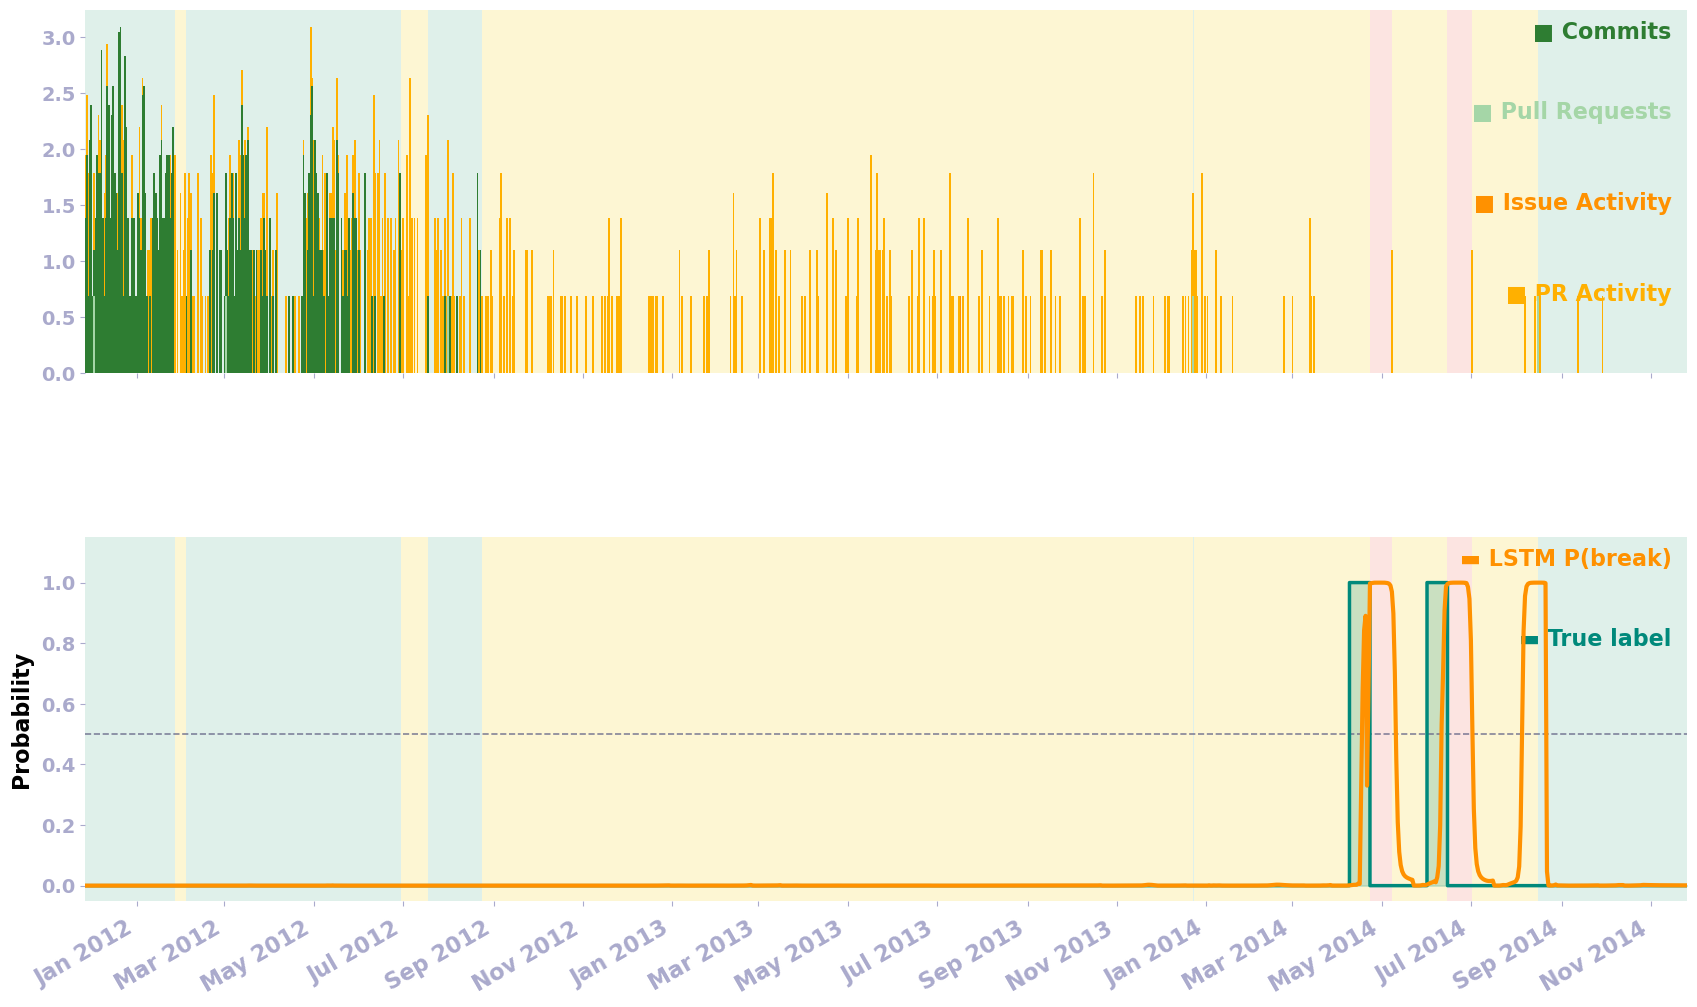

In [62]:
# ── Bold Colour Palette ───────────────────────────────────────────────────────
C_COMMITS  = "#2e7d32"   # dark green   (commits = coding)
C_PRS      = "#a5d6a7"   # light green  (PRs = also coding, distinguishable)
C_ISSACT   = "#FF9100"   # vivid yellow (issue activity)
C_PRACT    = "#ffb000"   # bright yellow(PR activity, lighter to distinguish)
C_PRED     = "#FF9100"   # vivid orange
C_TRUE     = "#00897b"   # teal green

BG         = "#ffffff"   # light blue — matches poster
PANEL_BG   = "#e8fbff"   # off white
GRID_COL   = "#000000"   # subtle grid lines

# ── figure ────────────────────────────────────────────────────────────────────
FONT = "DejaVu Sans"
plt.rcParams.update({
    "font.family":       FONT,
    "axes.spines.top":   False,
    "axes.spines.right": False,
    "axes.spines.left":  False,
    "axes.spines.bottom":False,
    "xtick.color":       "#aaaacc",
    "ytick.color":       "#aaaacc",
    "axes.labelcolor":   "#ffffff",
    "text.color":        "#ffffff",
    "font.weight":       "bold",
})

fig, axes = plt.subplots(
    2, 1,
    figsize=(18, 11),
    gridspec_kw={"height_ratios": [2, 2]},
    facecolor=BG,
)
fig.subplots_adjust(hspace=0.45, left=0.08, right=0.97, top=0.93, bottom=0.12)

dev_name = df["dev"].iloc[0] if "dev" in df.columns else "Developer"

date_fmt = mdates.DateFormatter("%b %Y")
date_loc = mdates.MonthLocator(interval=2)

# ── helper: bold panel label ──────────────────────────────────────────────────
def panel_title(ax, txt):
    ax.text(0.01, 0.97, txt, transform=ax.transAxes,
            fontsize=20, fontweight="bold", color="#000000",   # ← 13 → 20
            va="top", ha="left")

# ── Panel 1: Coding Activity ──────────────────────────────────────────────────
ax1 = axes[0]
ax1.set_facecolor(PANEL_BG)
shade_states(ax1, df)

mask_c = df["commits_log"] > 0
mask_p = df["prs_log"]     > 0
mask_ia = df["issue_act_log"] > 0
mask_pa = df["pr_act_log"]    > 0

ax1.bar(df.loc[mask_ia, "date"], df.loc[mask_ia, "issue_act_log"],
        width=1.2, color=C_ISSACT, alpha=1.0, zorder=1)
ax1.bar(df.loc[mask_pa, "date"], df.loc[mask_pa, "pr_act_log"],
        width=1.2, color=C_PRACT,  alpha=1.0, zorder=2)
ax1.bar(df.loc[mask_c, "date"], df.loc[mask_c, "commits_log"],
        width=1.2, color=C_COMMITS, alpha=1.0, zorder=3)
ax1.bar(df.loc[mask_p, "date"], df.loc[mask_p, "prs_log"],
        width=1.2, color=C_PRS,     alpha=1.0, zorder=4)
#panel_title(ax1, "CODING & NON-CODING ACTIVITY")

ax1.text(0.99, 0.97, "■ Commits", transform=ax1.transAxes,
         fontsize=16, color=C_COMMITS, va="top", ha="right", fontweight="bold")
ax1.text(0.99, 0.75, "■ Pull Requests", transform=ax1.transAxes,
         fontsize=16, color=C_PRS, va="top", ha="right", fontweight="bold")
ax1.text(0.99, 0.25, "■ PR Activity", transform=ax1.transAxes,
         fontsize=16, color=C_PRACT, va="top", ha="right", fontweight="bold")
ax1.text(0.99, 0.50, "■ Issue Activity", transform=ax1.transAxes,
         fontsize=16, color=C_ISSACT, va="top", ha="right", fontweight="bold")

ax1.tick_params(axis="y", labelsize=14)
ax1.xaxis.set_major_formatter(date_fmt)
ax1.xaxis.set_major_locator(date_loc)
plt.setp(ax1.get_xticklabels(), visible=False)



# ── Panel 3: LSTM Prediction vs Ground Truth ──────────────────────────────────
ax3 = axes[1]
ax3.set_facecolor(PANEL_BG)
shade_states(ax3, df)

pred_rows = df.dropna(subset=["y_pred"])

ax3.fill_between(df["date"], df["y_true"],
                 alpha=0.20, color=C_TRUE, zorder=2)
ax3.step(df["date"], df["y_true"],
         where="post", color=C_TRUE, linewidth=2.5, zorder=3)

if not pred_rows.empty:
    ax3.plot(pred_rows["date"], pred_rows["y_pred"],
             color=C_PRED, linewidth=3.0, zorder=4)

ax3.axhline(0.5, color="#666688", linestyle="--", linewidth=1.2, alpha=0.8)
ax3.set_ylim(-0.05, 1.15)
ax3.set_ylabel("Probability", fontsize=16, fontweight="bold", labelpad=6, color="#000000" )
ax3.tick_params(axis="y", labelsize=14)

#panel_title(ax3, "BREAK PREDICTION  (LSTM)")

ax3.text(0.99, 0.97, "▬ LSTM P(break)", transform=ax3.transAxes,
         fontsize=16, color=C_PRED, va="top", ha="right", fontweight="bold")
ax3.text(0.99, 0.75, "▬ True label", transform=ax3.transAxes,
         fontsize=16, color=C_TRUE, va="top", ha="right", fontweight="bold")

ax3.xaxis.set_major_formatter(date_fmt)
ax3.xaxis.set_major_locator(date_loc)
plt.setp(ax3.get_xticklabels(), rotation=30, ha="right",
         fontsize=16, fontweight="bold", color="#aaaacc")   # ← 11 → 16
ax3.tick_params(axis="x", labelsize=16, pad=8)

# ── shared x-limits ───────────────────────────────────────────────────────────
xlim = (df["date"].min(), df["date"].max())
for ax in axes:
    ax.set_xlim(*xlim)

# ── state legend ──────────────────────────────────────────────────────────────
state_handles = [
    mpatches.Patch(facecolor=c, edgecolor="#555577", linewidth=0.8, label=s)
    for s, c in STATE_LEGEND.items()
]
#fig.legend(
#    handles=state_handles,
#    loc="lower center", ncol=len(STATE_LEGEND),
#    fontsize=14,                      # ← 10 → 14
#    framealpha=0.3,
#    edgecolor="#555577",
#    facecolor=BG,
#    bbox_to_anchor=(0.5, 0.005),
#    title="Developer State", title_fontsize=14,   # ← 10 → 14
#    labelcolor="#000000",
#)

fig.savefig(OUTPUT_PNG, dpi=300, bbox_inches="tight", facecolor=BG)
fig.savefig(OUTPUT_PDF,           bbox_inches="tight", facecolor=BG)
print(f"Saved → {OUTPUT_PNG}")
print(f"Saved → {OUTPUT_PDF}")
plt.show()